In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
dt=pd.read_csv("Mall_Customers.csv")

In [3]:
dt.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
dt=dt.drop("CustomerID",axis=1)

In [5]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [6]:
dt.shape

(200, 4)

In [7]:
dt.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
dt.duplicated().sum()

np.int64(0)

In [9]:
dt.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [10]:
dt["Gender"]=dt["Gender"].replace({"Male":0,"Female":1})

In [11]:
dt.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.560000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,1.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


# Data visualization

## UNIVARIATE ANALYSIS (HISTO GRAM AND BOX PLOT)

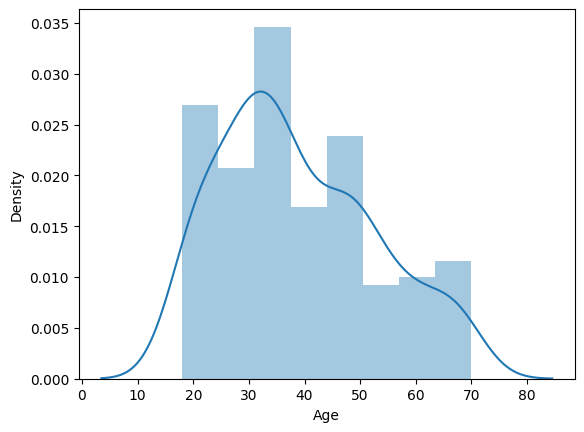

In [12]:
#Age Hisogram
sns.distplot(dt['Age'],kde=True)
plt.show()

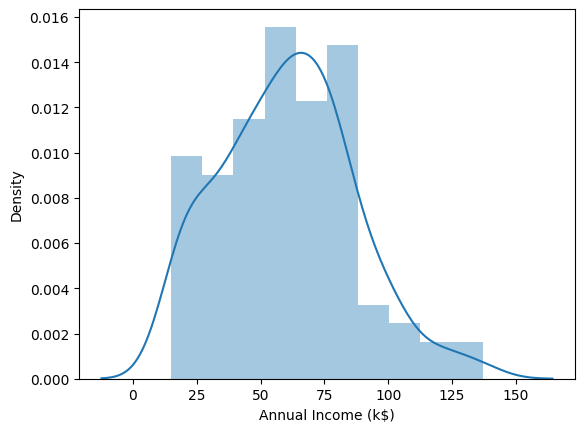

In [13]:
# Annual Income 
sns.distplot(dt['Annual Income (k$)'],kde=True)
plt.show()

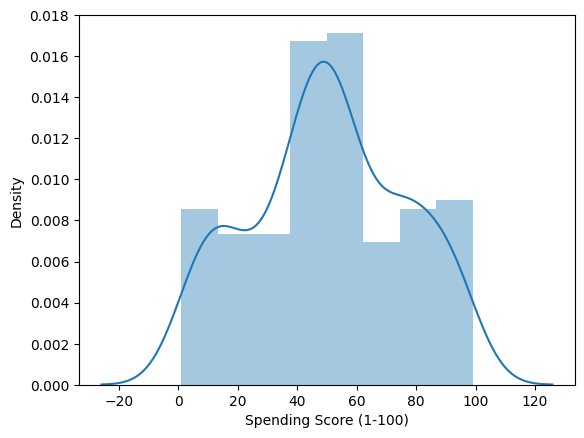

In [14]:
#spending score
sns.distplot(dt['Spending Score (1-100)'],kde=True)
plt.show()

In [15]:
# skewness for each column
for col in dt.columns:
    print(col,dt[col].skew())

Gender -0.24357754003130935
Age 0.48556885096681657
Annual Income (k$) 0.3218425498619055
Spending Score (1-100) -0.047220201374263374


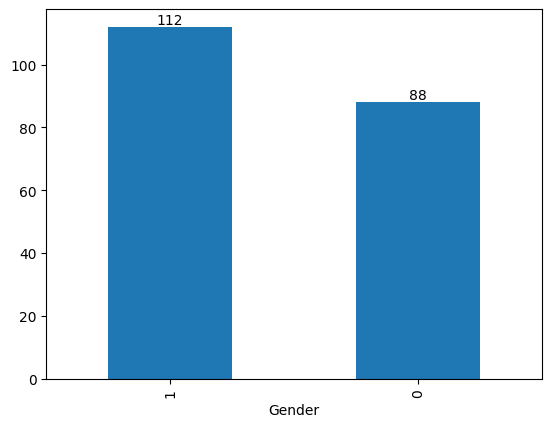

In [16]:
# bar chart for gender 
ax=dt["Gender"].value_counts().plot(kind="bar")

for  container in ax.containers:
    ax.bar_label(container)
plt.show()

# not much imbalance

### BOX PLOT FOR DETECTING OUTLIER 



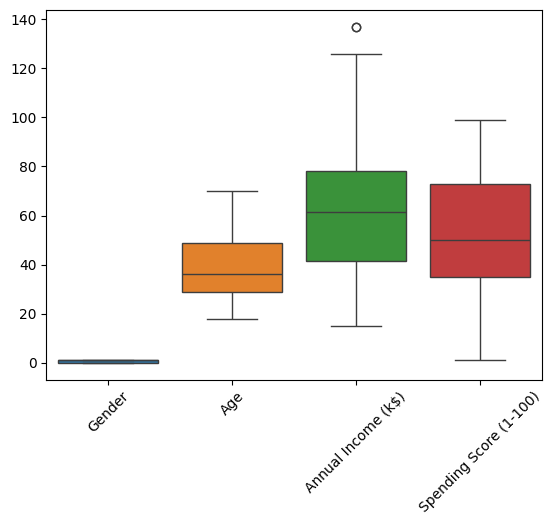

In [17]:
sns.boxplot(dt)
plt.xticks(rotation=45)
plt.show()

### lets use Z_SCORE TO DETECT OUTLIER 

In [18]:
from scipy import stats
from scipy.stats import zscore

In [19]:
dt_z=dt.apply(zscore)

(dt_z>3).sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### BI-VARIATE ANALYSIS

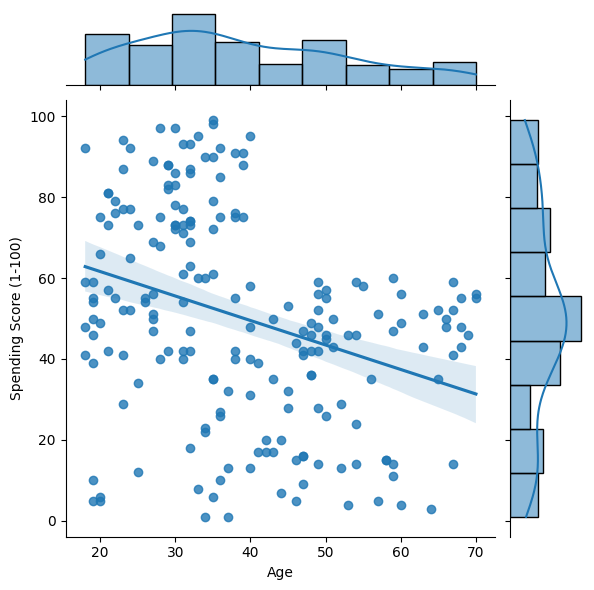

In [20]:
# Age vs Spending Score
sns.jointplot(x="Age",y="Spending Score (1-100)",data=dt,kind='reg')
plt.show()

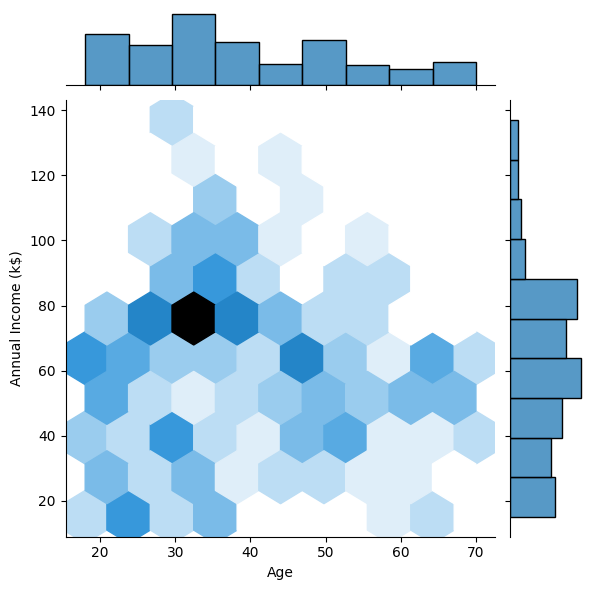

In [21]:
# Age vs Annual Income  plot 

sns.jointplot(x='Age',y="Annual Income (k$)",data=dt,kind='hex')
plt.show()

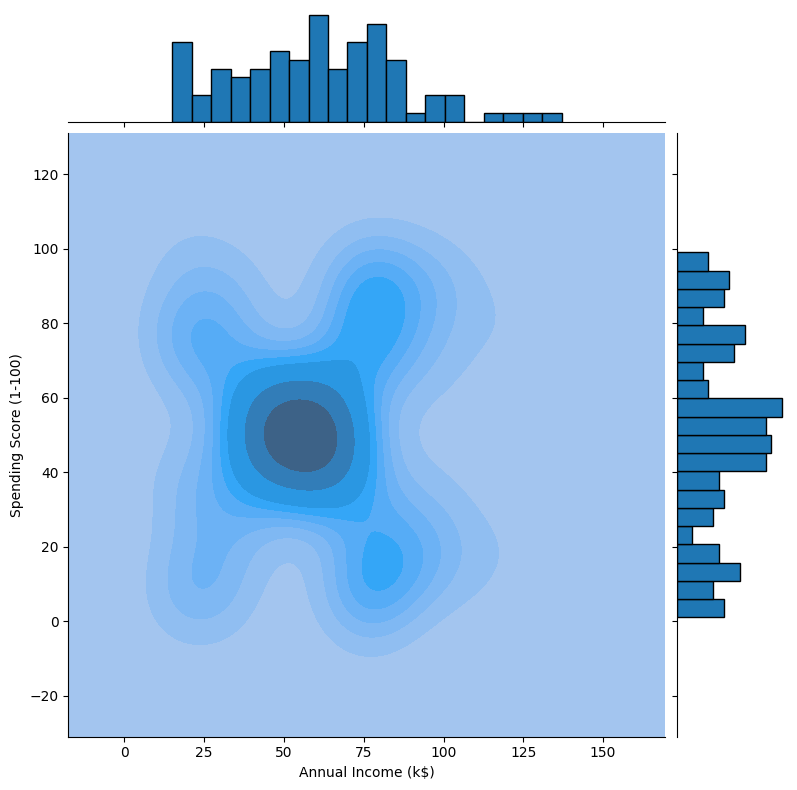

In [22]:
g = sns.JointGrid(data = dt, height = 8, x = "Annual Income (k$)", y = "Spending Score (1-100)", space = 0.1)
g.plot_joint(sns.kdeplot, fill = True, thresh = 0)
g.plot_marginals(sns.histplot, alpha = 1, bins = 20);

In [23]:
dt.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


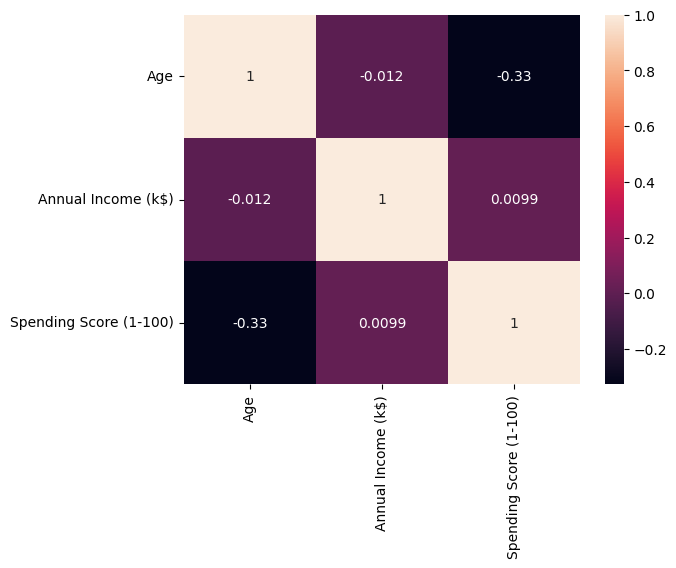

In [24]:
col=['Age','Annual Income (k$)','Spending Score (1-100)']
dt_corr=dt[col].corr()
sns.heatmap(dt_corr,annot=True)
plt.show()

In [25]:
scale_col=["Age","Annual Income (k$)","Spending Score (1-100)"]

from sklearn.preprocessing import StandardScaler

sd=StandardScaler()

dt[scale_col]=sd.fit_transform(dt[scale_col])

In [26]:
dt.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,-1.424569,-1.738999,-0.434801
1,0,-1.281035,-1.738999,1.195704
2,1,-1.352802,-1.700830,-1.715913
3,1,-1.137502,-1.700830,1.040418
4,1,-0.563369,-1.662660,-0.395980


## Building Clustering model 

In [27]:
# Finding optimal number of cluster using elbow method 

In [28]:
from sklearn.cluster import KMeans

In [29]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(dt)
    wcss.append(kmeans.inertia_)

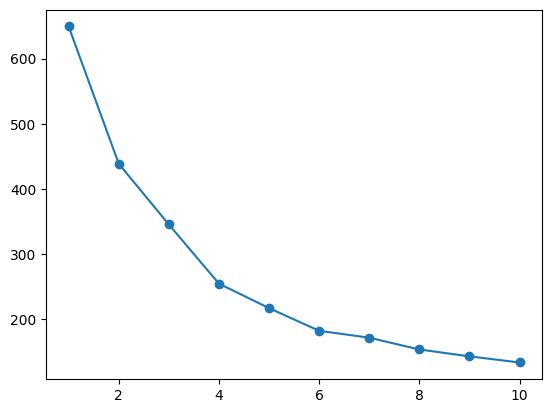

In [30]:
plt.plot(range(1,11),wcss,marker="o")
plt.show()

### MODELING USING K MEANS CLUSTERING

In [31]:
kmeans1=KMeans(n_clusters=4,init='k-means++',random_state=42)
kmeans1.fit(dt)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [32]:
print(kmeans1.cluster_centers_)
print(kmeans1.labels_)
print(kmeans1.inertia_)

[[ 0.578125    1.08053722 -0.50445672 -0.37960207]
 [ 0.55       -0.42880597  0.97484722  1.21608539]
 [ 0.59649123 -0.96249203 -0.78476346  0.39202966]
 [ 0.48717949  0.07333084  0.97494509 -1.19729675]]
[2 2 2 2 2 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 2 0 0 2 0 0 2 2 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 3 2 2 2 0 0 0 0 2 3 1 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
254.36171423484492


In [33]:
# calculate the silhute score
from sklearn.metrics import silhouette_score

In [34]:

print("The Silhouette_score is :",silhouette_score(dt,kmeans1.labels_,metric='euclidean'))

The Silhouette_score is : 0.35044061449694197


In [35]:
from yellowbrick.cluster import SilhouetteVisualizer 

In [36]:
cluster=kmeans1.fit_predict(dt.iloc[:,1:])
dt["label"]=cluster

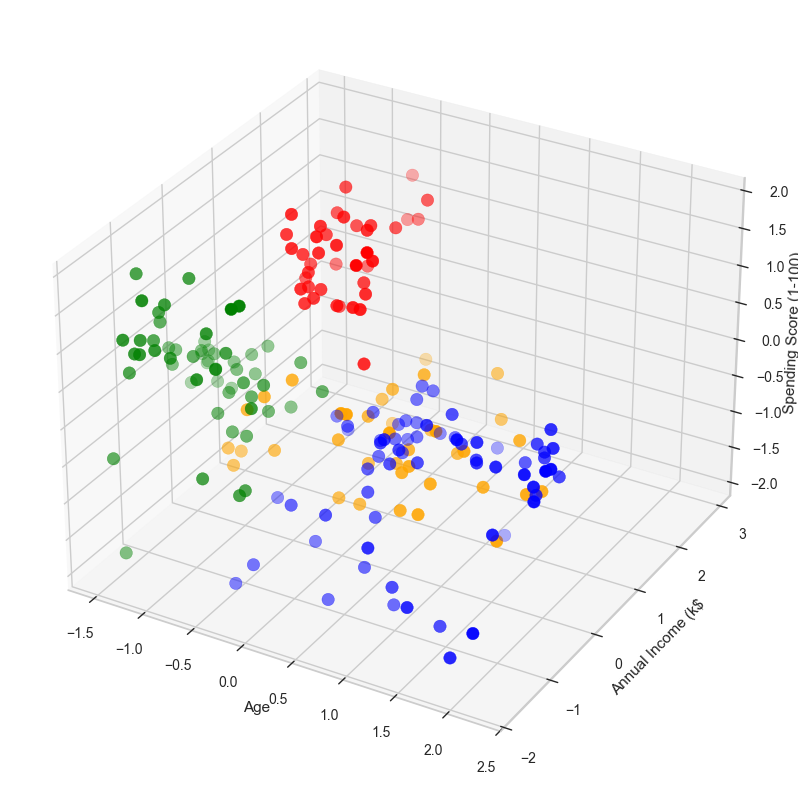

In [37]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(dt.Age[dt["label"] == 0], dt["Annual Income (k$)"][dt["label"] == 0], dt["Spending Score (1-100)"][dt["label"] == 0], c='blue', s=80)
ax.scatter(dt.Age[dt["label"] == 1], dt["Annual Income (k$)"][dt["label"] == 1], dt["Spending Score (1-100)"][dt["label"] == 1], c='red', s=80)
ax.scatter(dt.Age[dt["label"] == 2], dt["Annual Income (k$)"][dt["label"] == 2], dt["Spending Score (1-100)"][dt["label"] == 2], c='green', s=80)
ax.scatter(dt.Age[dt["label"] == 3], dt["Annual Income (k$)"][dt["label"] == 3], dt["Spending Score (1-100)"][dt["label"] == 3], c='orange', s=80)
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$")
ax.set_zlabel("Spending Score (1-100)")
plt.show()

In [38]:
# it is clear from the graph the cluster are not seprated very well we need to do feature engineering now

#### Implementing PCA

In [39]:
from sklearn.decomposition import PCA

In [40]:
pca=PCA(n_components=4)
principalComponents=pca.fit_transform(dt)

In [41]:
pca.explained_variance_ratio_

array([0.40705657, 0.27557423, 0.20758858, 0.05705249])

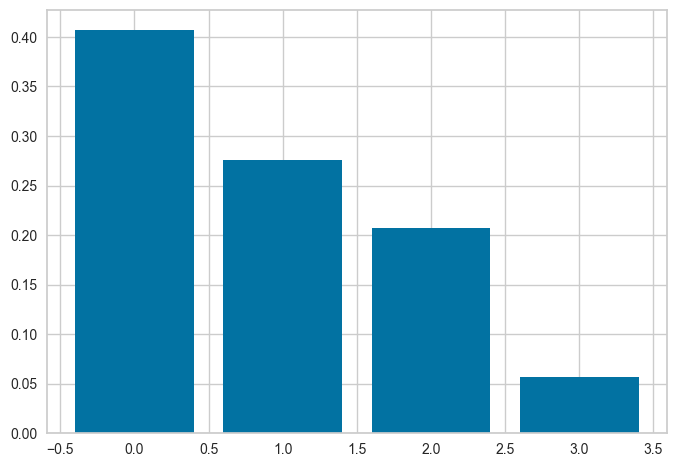

In [42]:
features=range(pca.n_components)
plt.bar(features,pca.explained_variance_ratio_)
plt.show()

In [43]:
# first two features explain the 70% of the variance of the model we will feed these two features to the model 

In [44]:
PCA_Components=pd.DataFrame(principalComponents)

# lets create new model based on Principle Componenets

In [45]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(PCA_Components.iloc[:,:2])
    wcss.append(kmeans.inertia_)

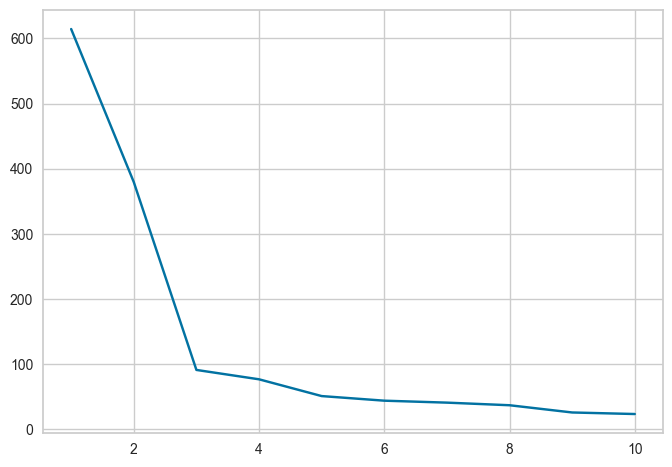

In [46]:
plt.plot(range(1,11),wcss)
plt.show()

In [47]:
# it seems like after pca and using elbow the number of optimal cluster is 4 

In [48]:
kmeans2=KMeans(n_clusters=4,init="k-means++",random_state=42)
kmeans2.fit(PCA_Components.iloc[:,:2])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [49]:
print(kmeans2.cluster_centers_)
print(kmeans2.labels_)
print(kmeans2.inertia_)

[[-1.54576275 -0.00335053]
 [ 0.62901313  0.86923851]
 [-2.17284181 -0.72342909]
 [ 1.48398525 -1.70147975]]
[1 1 1 1 1 1 0 1 2 1 2 1 2 1 0 1 1 1 2 1 1 1 2 1 2 1 0 1 0 1 2 1 2 1 2 1 0
 1 0 1 2 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 2 1 0 2 1 2 0 2 1 0 2 1 1 2 0 0 0
 2 1 0 0 1 0 0 1 2 0 1 0 0 1 1 0 2 1 0 0 1 1 0 1 0 1 1 0 2 1 0 1 2 0 2 2 2
 1 3 1 1 1 2 0 0 0 1 3 1 1 3 1 3 1 2 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 2 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]
76.71107906307556


In [50]:
#shilute score
print("Silhute score after pca is :",silhouette_score(PCA_Components.iloc[:,:2], kmeans1.labels_, metric='euclidean')) 

Silhute score after pca is : 0.4309061924581659


In [51]:
# analysis

In [53]:
dt1=pd.read_csv("Mall_Customers.csv")

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [63]:
dt1["Gender"]=dt1["Gender"].replace({"Male":0,"Female":1})
dt1.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [77]:
dt1=dt1.drop("CustomerID",axis=1)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [79]:
pred=kmeans2.labels_
frame=pd.DataFrame(dt1)
frame["cluster"]=pred

In [95]:
frame.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,0,19,15,39,1
1,0,21,15,81,1
2,1,20,16,6,1
3,1,23,16,77,1
4,1,31,17,40,1


In [81]:
avg_df=frame.groupby(["cluster"]).mean()
avg_df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,0.684211,48.157895,48.815789,43.921053
1,0.577320,28.505155,59.010309,69.051546
2,0.407407,62.185185,46.148148,34.407407
3,0.500000,39.368421,86.500000,19.578947


In [ ]:
# lets draw subplot and visualize it 

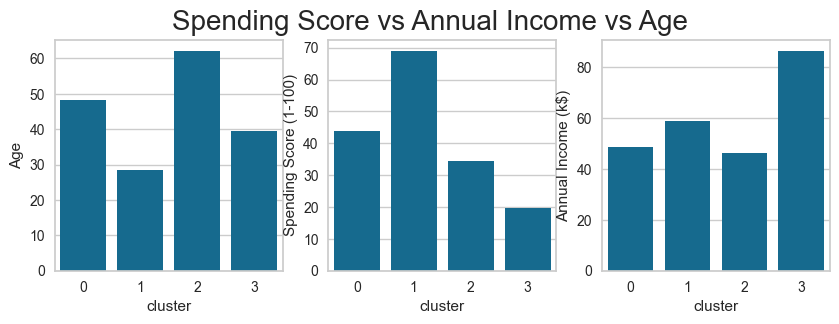

In [86]:
f,ax=plt.subplots(nrows=1,ncols=3,figsize=(10,3))
sns.barplot(x="cluster",y="Age",data=avg_df,ax=ax[0])
sns.barplot(x="cluster",y="Spending Score (1-100)",data=avg_df,ax=ax[1])
sns.barplot(x="cluster",y="Annual Income (k$)",data=avg_df,ax=ax[2])
plt.suptitle('Spending Score vs Annual Income vs Age',fontsize=20)
plt.show()

In [93]:
frame.groupby("cluster")["Gender"].value_counts()

cluster  Gender
0        1         26
         0         12
1        1         56
         0         41
2        0         16
         1         11
3        0         19
         1         19
Name: count, dtype: int64

From the above visualisations we can observe the following things:

Cluster 3:

High average annual income, low average spending capacity.

Cluster 1:

High average income, high spending score.

Cluster 2:

Low average income, high spending score.
Mean age is around 25 and gender is predominantly female.
Cluster 0:

Low to mid average income, average spending capacity.
Mean age is around 50 and gender is predominantly female.